In [1]:
import freetype
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import skeletonize
from PIL import Image, ImageDraw


In [2]:
face = freetype.Face("../fonts/字悦九叠印篆.ttf")

In [9]:
char = "胬"

In [32]:
face.units_per_EM

1000

In [10]:
# face.set_pixel_sizes(0, face.units_per_EM)
face.set_pixel_sizes(0, 500)
# 1. 仅加载字形轮廓（Outline）
face.load_char(char, freetype.FT_LOAD_DEFAULT)

# 2. 显式将其渲染为位图
face.glyph.render(freetype.FT_RENDER_MODE_NORMAL)

# 3. 此时再获取位图
bmp = face.glyph.bitmap

In [11]:
face.glyph.outline.contours

[23, 57, 65, 69, 71, 97]

In [75]:
face.glyph.outline.contours

[44, 64, 84, 104, 124]

In [12]:
# face.load_char(char, freetype.FT_LOAD_RENDER)
# glyph = face.glyph

# bmp = glyph.bitmap
# 检查位图是否有效
mask = np.array(bmp.buffer).reshape(bmp.rows, bmp.width)


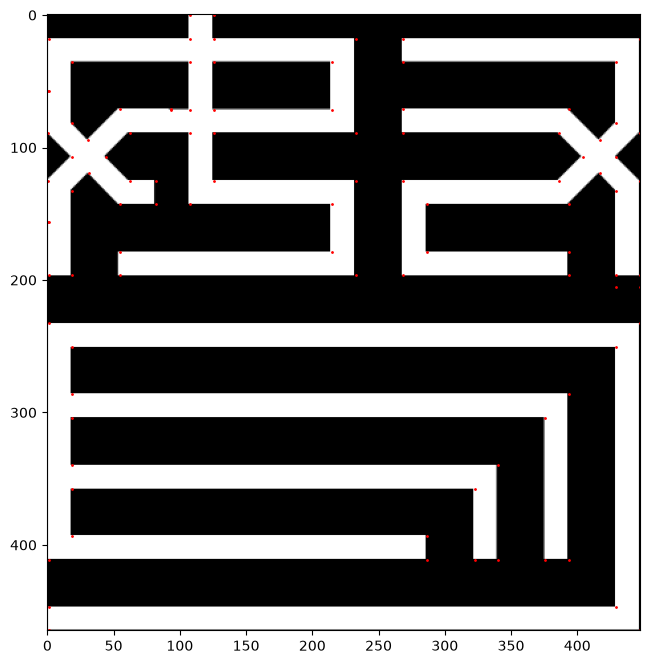

In [13]:
face.load_char(char, freetype.FT_LOAD_NO_HINTING)

outline = face.glyph.outline
points = np.array(outline.points) / 64.0  # 26.6 fixed point -> pixel

glyph = face.glyph
left = glyph.bitmap_left
top = glyph.bitmap_top


skeleton = skeletonize(mask)
x = points[:, 0] - left
y = top - points[:, 1]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(mask, cmap="gray", origin="upper")
# ax.imshow(skeleton, "gray")
ax.plot(x, y, "r.", ms=2)
ax.set_aspect("equal")
plt.show()

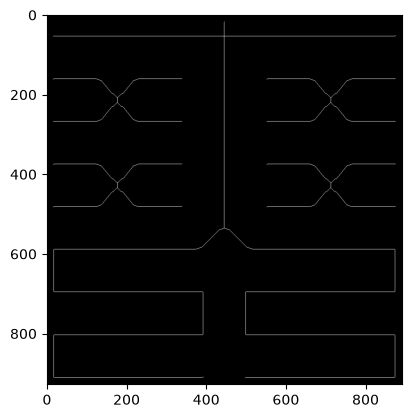

In [ ]:
skeleton_points = np.nonzero(skeleton)

In [ ]:
skeleton_points

(array([ 17,  18,  19, ..., 910, 910, 910], shape=(7848,)),
 array([446, 445, 445, ..., 871, 872, 873], shape=(7848,)))

In [ ]:
skeleton_xy = np.stack(skeleton_points, axis=1)

In [ ]:
skeleton_xy

array([[ 17, 446],
       [ 18, 445],
       [ 19, 445],
       ...,
       [910, 871],
       [910, 872],
       [910, 873]], shape=(7848, 2))

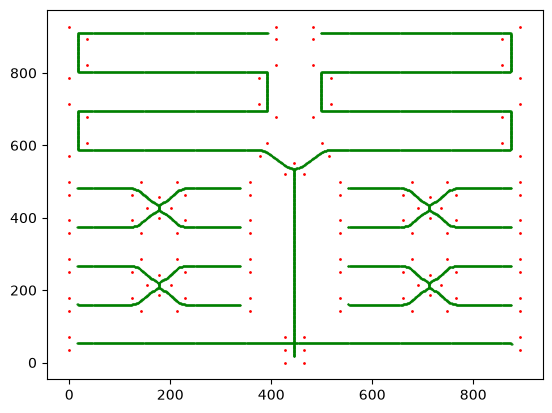

In [ ]:
plt.plot(skeleton_points[1], skeleton_points[0], "g.", ms=1)
plt.plot(x, y, "r.", ms=2)

In [ ]:
new_points = np.stack((y, x), axis=1)

In [ ]:
np.linalg.norm(skeleton_xy - new_points[0], axis=1)

array([888.97525275, 887.60858491, 886.74348038, ..., 879.78235945,
       880.7723883 , 881.76243966], shape=(7848,))

In [ ]:
new_points.shape

(125, 2)

In [ ]:
def distance(p, skeleton):
    return np.min(np.linalg.norm(skeleton - p, ord=2, axis=1))

In [ ]:
ds = []
for p in new_points:
    d = distance(np.array(p), skeleton_xy)
    ds.append(d.item())
ds = np.array(ds)

In [ ]:
bins, counts = np.unique(ds, return_counts=True)

<BarContainer object of 25 artists>

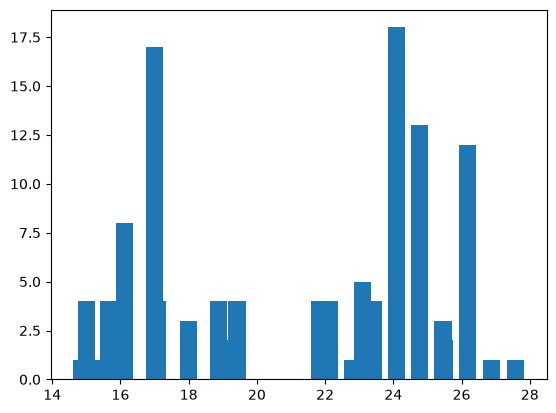

In [ ]:
plt.bar(bins, counts, width=0.5)

In [ ]:
import math


math.sqrt(2) * 17

24.041630560342618

In [55]:
face.set_pixel_sizes(0, face.units_per_EM)
face.load_char("爽", freetype.FT_LOAD_RENDER | freetype.FT_LOAD_NO_HINTING)

bmp = face.glyph.bitmap
mask = np.array(bmp.buffer).reshape(bmp.rows, bmp.width) > 0

In [57]:
char = "爽"

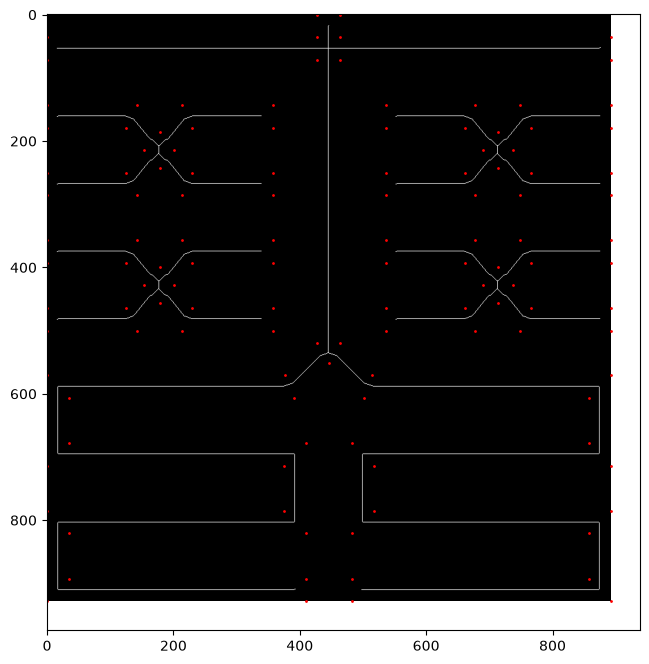

In [85]:
face.set_pixel_sizes(0, face.units_per_EM)

face.load_char(char, freetype.FT_LOAD_NO_HINTING)

outline = face.glyph.outline
points = np.array(outline.points) / 64.0  # 26.6 fixed point -> pixel

glyph = face.glyph
left = glyph.bitmap_left
top = glyph.bitmap_top

face.load_char(char, freetype.FT_LOAD_RENDER | freetype.FT_LOAD_NO_HINTING)

bmp = glyph.bitmap
mask = np.array(bmp.buffer).reshape(bmp.rows, bmp.width)

x = points[:, 0] - left
y = top - points[:, 1]

fig, ax = plt.subplots(figsize=(8, 8))
# ax.imshow(mask, cmap="gray", origin="upper")
ax.imshow(skeleton, "gray")
ax.plot(x, y, "r.", ms=2)
ax.set_aspect("equal")
plt.show()

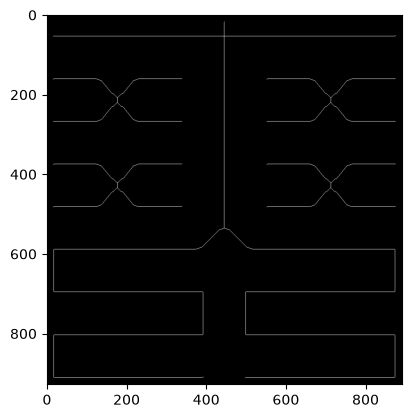

In [84]:
skeleton = skeletonize(mask)
plt.imshow(skeleton, cmap="gray")

In [87]:
skeleton_points = np.nonzero(skeleton)

In [88]:
skeleton_points

(array([ 17,  18,  19, ..., 910, 910, 910], shape=(7848,)),
 array([446, 445, 445, ..., 871, 872, 873], shape=(7848,)))

In [89]:
skeleton_xy = np.stack(skeleton_points, axis=1)

In [106]:
skeleton_xy

array([[ 17, 446],
       [ 18, 445],
       [ 19, 445],
       ...,
       [910, 871],
       [910, 872],
       [910, 873]], shape=(7848, 2))

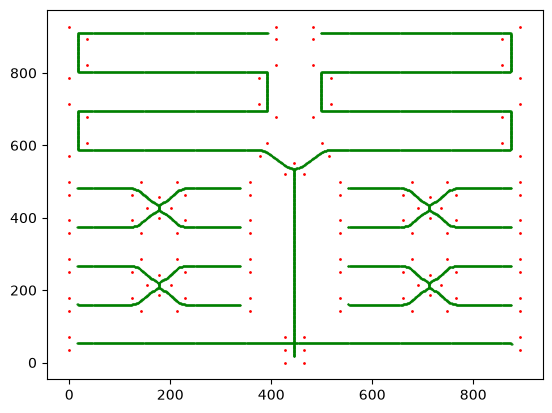

In [102]:
plt.plot(skeleton_points[1], skeleton_points[0], "g.", ms=1)
plt.plot(x, y, "r.", ms=2)

In [65]:
skeleton

array([[ 17, 446],
       [ 18, 445],
       [ 19, 445],
       ...,
       [910, 871],
       [910, 872],
       [910, 873]], shape=(7848, 2))

In [66]:
points

array([[  45.,   -4.],
       [ 420.,   -4.],
       [ 420.,   68.],
       [  45.,   68.],
       [  45.,  211.],
       [ 422.,  211.],
       [ 473.,  262.],
       [ 473.,  711.],
       [  45.,  711.],
       [  45.,  746.],
       [ 473.,  746.],
       [ 473.,  782.],
       [ 509.,  782.],
       [ 509.,  746.],
       [ 938.,  746.],
       [ 938.,  711.],
       [ 509.,  711.],
       [ 509.,  262.],
       [ 560.,  211.],
       [ 938.,  211.],
       [ 938.,   68.],
       [ 563.,   68.],
       [ 563.,   -4.],
       [ 938.,   -4.],
       [ 938., -146.],
       [ 527., -146.],
       [ 527., -111.],
       [ 902., -111.],
       [ 902.,  -39.],
       [ 527.,  -39.],
       [ 527.,  104.],
       [ 902.,  104.],
       [ 902.,  175.],
       [ 546.,  175.],
       [ 491.,  230.],
       [ 436.,  175.],
       [  80.,  175.],
       [  80.,  104.],
       [ 455.,  104.],
       [ 455.,  -39.],
       [  80.,  -39.],
       [  80., -111.],
       [ 455., -111.],
       [ 45

In [103]:
new_points = np.stack((y, x), axis=1)

In [110]:
np.linalg.norm(skeleton_xy - new_points[0], axis=1)

array([888.97525275, 887.60858491, 886.74348038, ..., 879.78235945,
       880.7723883 , 881.76243966], shape=(7848,))

In [79]:
new_points.shape

(125, 2)

In [131]:
def distance(p, skeleton):
    return np.min(np.linalg.norm(skeleton - p, ord=2, axis=1))

In [142]:
ds = []
for p in new_points:
    d = distance(np.array(p), skeleton_xy)
    ds.append(d.item())
ds = np.array(ds)

In [138]:
from scipy.spatial.distance import cdist

In [145]:
ds_ = cdist(new_points, skeleton_xy).min(axis=1).astype(int)

In [147]:
values, counts = np.unique(ds_, return_counts=True)

In [148]:
d = values[counts.argmax()]

In [150]:
d

np.int64(24)

In [134]:
bins, counts = np.unique(ds, return_counts=True)

<BarContainer object of 25 artists>

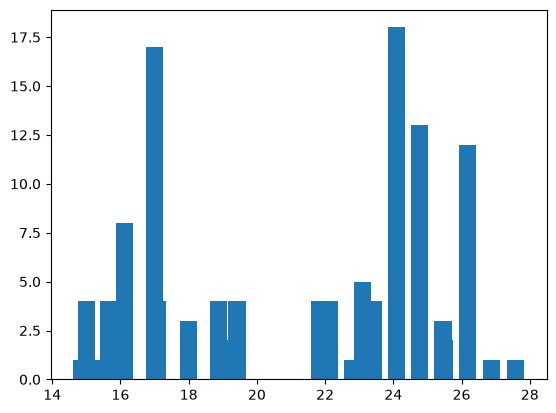

In [135]:
plt.bar(bins, counts, width=0.5)

In [137]:
import math


math.sqrt(2) * 17

24.041630560342618

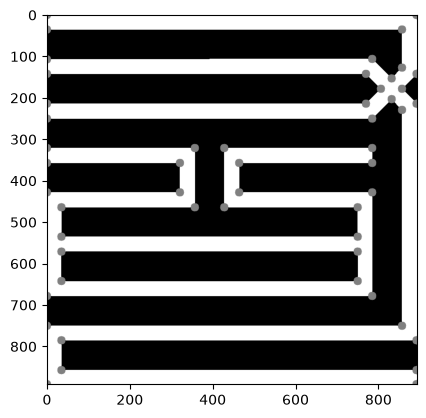

In [40]:
plt.imshow(canvas, cmap="gray")

In [ ]:
import numpy as np
import freetype
import cv2


def get_glyph_mask_and_points(font_path: str, char: str):
    """
    加载指定字符的矢量轮廓，并生成完美 Even-Odd 填充的 NumPy Mask 及原始控制点。

    参数:
        font_path: 字体文件的路径
        char: 要提取的单个字符

    返回:
        mask: np.ndarray, 二维灰度图像矩阵（含128灰度值的控制点圈）
        polygons: list of np.ndarray, 包含每个闭合轮廓坐标的列表（已转换到图像坐标系）
    """
    # 1. 载入字体并以矢量原始单位加载
    face = freetype.Face(font_path)
    face.load_char(char, freetype.FT_LOAD_NO_SCALE)
    outline = face.glyph.outline

    points = np.array(outline.points, dtype=np.int32)
    contours = outline.contours

    # 2. 计算全局边界
    x_min, y_min = points.min(axis=0)
    x_max, y_max = points.max(axis=0)

    width = int(x_max - x_min)
    height = int(y_max - y_min)

    # 3. 一次性转换所有点的坐标：平移 + Y轴翻转
    new_points = points.copy()
    new_points[:, 0] = new_points[:, 0] - x_min
    new_points[:, 1] = height - (new_points[:, 1] - y_min)

    # 4. 解析轮廓，直接使用已转换的坐标
    polygons = []
    start = 0
    for end in contours:
        contour_pts = new_points[start : end + 1]
        polygons.append(contour_pts)
        start = end + 1

    # 5. 初始化画布
    mask = np.zeros((height, width), dtype=np.uint8)

    # 6. 异或绘制 Mask 填充 (Even-Odd 规则)
    for poly in polygons:
        cv_poly = poly.reshape((-1, 1, 2))
        temp_mask = np.zeros_like(mask)
        cv2.drawContours(temp_mask, [cv_poly], -1, 255, thickness=cv2.FILLED)
        mask = cv2.bitwise_xor(mask, temp_mask)

    return mask, new_points

In [64]:
mask, points = get_glyph_mask_and_points("../fonts/字悦九叠印篆.ttf", "右")

In [66]:
from skimage.morphology import skeletonize

skeleton = skeletonize(mask)

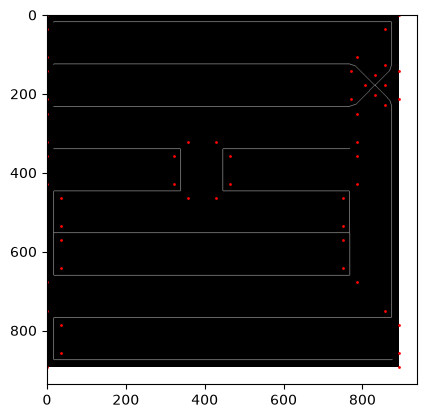

In [67]:
# plt.imshow(mask, cmap="gray")
plt.imshow(skeleton, cmap="gray")
for p in points:
    plt.plot(p[0], p[1], "r.", ms=2)